# S0 — Historical P–ET–R catalog analysis / 历史情景 P–ET–R 目录分析

This notebook does **not** download climate files. It queries the local CMIP6 historical attribute catalog and asks one design question:

> Which models have `pr` (Amon), `evspsbl` (Amon) and `mrro` (Lmon) on a **common member**, with index dates that can support a 1985–2014 monthly analysis?

The catalog itself stays unfiltered (all 1103 variables). The P–ET–R rule is only an analysis overlay.

**中文说明：** 本 notebook 不下气候数据。它只查本地的 CMIP6 historical 属性目录，回答一个研究设计问题：哪些模型能在**同一个 member** 上同时提供大气月平均降水 `pr`、大气月平均蒸发 `evspsbl`、陆面月平均径流 `mrro`，并且索引时间大致覆盖 1985–2014。目录本身仍是全变量；这里的规则只是叠在上面的一次查询。

## 1. Configuration / 配置

Use the raw Dataset-level jsonl when available. That file still has `table_id`, `member_id` and dates on each record. The wide/long Excel summary mixes all tables of one variable into one row, so it cannot reliably test member matching.

**中文说明：** 优先用带 `table_id` / `member_id` / 日期的原始 Dataset 记录。Excel 长表把一个变量的所有 table 收成一行，不能可靠地做 member 对齐。

In [1]:
from __future__ import annotations

import json
import re
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display


def locate_case_dir() -> Path:
    candidates = [Path.cwd().resolve(), *Path.cwd().resolve().parents]
    for candidate in candidates:
        if candidate.name == "caseA" and (candidate / "cmip_utils.py").exists():
            return candidate
        nested = candidate / "case" / "caseA"
        if (nested / "cmip_utils.py").exists():
            return nested
    raise FileNotFoundError("Could not locate case/caseA")


CASE_DIR = locate_case_dir()
CATALOG_JSONL = CASE_DIR.parents[1] / ".tmp_cmip6_matrix_work" / "esgf_historical_model_variable_docs.jsonl"
SUMMARY_CSV = CASE_DIR / "CMIP6_ESGF_historical_model_variable_attributes.csv"
OUT_DIR = CASE_DIR / "derived" / "catalog_s0"
OUT_DIR.mkdir(parents=True, exist_ok=True)

CORE = [
    ("pr", "Amon"),
    ("evspsbl", "Amon"),
    ("mrro", "Lmon"),
]
CONTEXT = [
    ("tas", "Amon"),
    ("rsds", "Amon"),
    ("rsus", "Amon"),
    ("rlds", "Amon"),
    ("rlus", "Amon"),
    ("mrso", "Lmon"),
    ("lai", "Lmon"),
    ("snw", "LImon"),
    ("sftlf", "fx"),
    ("areacella", "fx"),
]

ANALYSIS_START_YEAR = 1985
PASS_STOP = pd.Timestamp("2014-12-01", tz="UTC")
FLAG_STOP = pd.Timestamp("2012-01-01", tz="UTC")
MEMBER_RE = re.compile(r"^r(\d+)i(\d+)p(\d+)f(\d+)$")
FAMILY_RULES = [
    (r"^CESM2", "CESM2"),
    (r"^CanESM5", "CanESM5"),
    (r"^EC-Earth3", "EC-Earth3"),
    (r"^HadGEM3-GC31", "HadGEM3-GC31"),
    (r"^MPI-ESM-?1-2", "MPI-ESM1-2"),
    (r"^NorESM2", "NorESM2"),
    (r"^UKESM1", "UKESM1"),
    (r"^E3SM-", "E3SM"),
    (r"^MIROC-ES2", "MIROC-ES2"),
    (r"^CMCC-CM2-", "CMCC-CM2"),
    (r"^FGOALS-f3-", "FGOALS-f3"),
    (r"^CNRM-CM6-1", "CNRM-CM6-1"),
    (r"^IPSL-CM6A-LR", "IPSL-CM6A-LR"),
    (r"^GISS-E2-1", "GISS-E2-1"),
    (r"^GISS-E2-2", "GISS-E2-2"),
]

print("Case directory:", CASE_DIR)
print("Raw catalog:", CATALOG_JSONL, "exists=" + str(CATALOG_JSONL.is_file()))
print("Summary CSV:", SUMMARY_CSV, "exists=" + str(SUMMARY_CSV.is_file()))
print("Output:", OUT_DIR)

Case directory: /Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/case/caseA
Raw catalog: /Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/.tmp_cmip6_matrix_work/esgf_historical_model_variable_docs.jsonl exists=True
Summary CSV: /Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/case/caseA/CMIP6_ESGF_historical_model_variable_attributes.csv exists=True
Output: /Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/case/caseA/derived/catalog_s0


## 2. Load the local catalog / 读取本地目录

Replica copies of the same `master_id` are dropped; a non-replica record is kept when both exist.

**中文说明：** 同一 `master_id` 的副本只留一条；同时有正本和副本时留正本。

In [2]:
def family_of(model: str) -> str:
    for pattern, name in FAMILY_RULES:
        if re.search(pattern, model):
            return name
    return model


def member_key(member: str):
    match = MEMBER_RE.fullmatch(member or "")
    if match:
        return (0, *(int(part) for part in match.groups()), member)
    return (1, 9999, 9999, 9999, 9999, member or "")


def parse_time(value):
    if value is None or value == "" or (isinstance(value, float) and pd.isna(value)):
        return pd.NaT
    return pd.to_datetime(value, utc=True, errors="coerce")


def period_status(start, stop) -> str:
    if pd.isna(start):
        return "Fail"
    if start.year > ANALYSIS_START_YEAR:
        return "Fail"
    if pd.isna(stop):
        return "Flag"  # fx-like or incomplete index; keep but review
    if stop >= PASS_STOP:
        return "Pass"
    if stop >= FLAG_STOP:
        return "Flag"
    return "Fail"


if not CATALOG_JSONL.is_file():
    raise FileNotFoundError(
        f"Missing {CATALOG_JSONL}. Rebuild the historical attribute catalog first."
    )

raw = pd.read_json(CATALOG_JSONL, lines=True)
raw = raw.dropna(subset=["source_id", "variable_id", "table_id", "member_id"])
raw["replica"] = raw["replica"].fillna(False).astype(bool)
raw = raw.sort_values(["master_id", "replica"])
docs = raw.drop_duplicates("master_id", keep="first").copy()
docs["start"] = docs["datetime_start"].map(parse_time)
docs["stop"] = docs["datetime_stop"].map(parse_time)
docs["period"] = [period_status(s, e) for s, e in zip(docs["start"], docs["stop"])]
docs["family"] = docs["source_id"].map(family_of)

summary = pd.read_csv(SUMMARY_CSV) if SUMMARY_CSV.is_file() else None
print(f"Raw records: {len(raw):,}")
print(f"Unique Dataset records: {len(docs):,}")
print(f"Models: {docs['source_id'].nunique()}")
print(f"Variables: {docs['variable_id'].nunique()}")
if summary is not None:
    print(f"Summary CSV rows (model × variable): {len(summary):,}")

Raw records: 622,335
Unique Dataset records: 273,607
Models: 75
Variables: 1103
Summary CSV rows (model × variable): 19,130


## 3. Catalog overview / 目录总览

This is the unfiltered historical archive: all variables, all tables.

**中文说明：** 这是未筛选的 historical 档案总览：全部变量、全部 table。

,metric,count
0,Models,75
1,Variables,1103
2,Unique Dataset records,273607
3,Distinct tables,37
4,Model × variable pairs in summary CSV,19130


,table_id,n_datasets
0,Omon,59003
1,Amon,43340
2,Emon,27778
3,SImon,23970
4,Lmon,20010
5,day,17523
6,AERmon,17346
7,Oyr,12296
8,Eday,6132
9,CFmon,5907


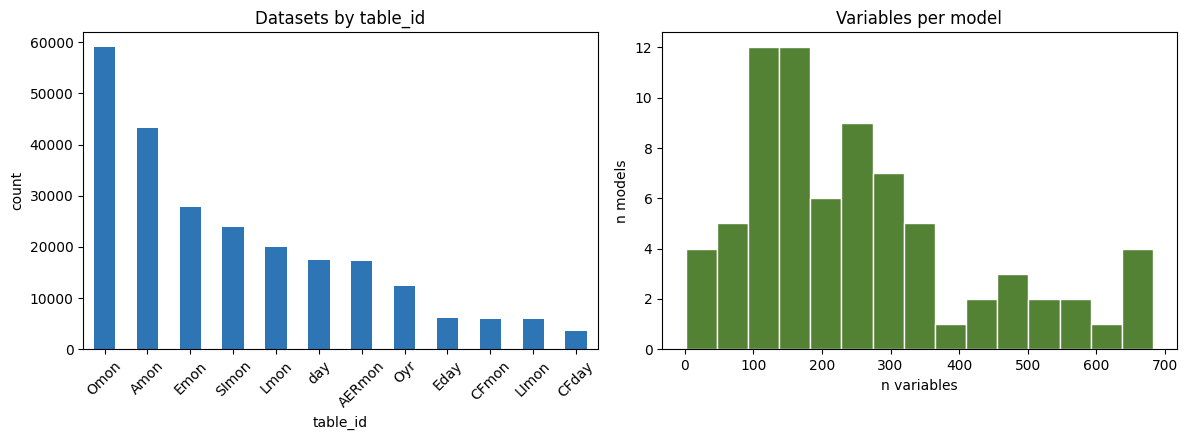

In [3]:
overview = pd.DataFrame(
    {
        "metric": [
            "Models",
            "Variables",
            "Unique Dataset records",
            "Distinct tables",
            "Model × variable pairs in summary CSV",
        ],
        "count": [
            docs["source_id"].nunique(),
            docs["variable_id"].nunique(),
            len(docs),
            docs["table_id"].nunique(),
            len(summary) if summary is not None else pd.NA,
        ],
    }
)
display(overview)

table_counts = (
    docs.groupby("table_id").size().sort_values(ascending=False).rename("n_datasets").reset_index()
)
display(table_counts.head(15))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
table_counts.head(12).plot.bar(x="table_id", y="n_datasets", ax=axes[0], legend=False, color="#2E75B6")
axes[0].set_title("Datasets by table_id")
axes[0].set_ylabel("count")
axes[0].tick_params(axis="x", rotation=45)

var_by_model = docs.groupby("source_id")["variable_id"].nunique().sort_values(ascending=False)
axes[1].hist(var_by_model, bins=15, color="#548235", edgecolor="white")
axes[1].set_title("Variables per model")
axes[1].set_xlabel("n variables")
axes[1].set_ylabel("n models")
fig.tight_layout()
fig.savefig(OUT_DIR / "S0_catalog_overview.png", dpi=150)
plt.show()

## 4. P–ET–R overlay query / P–ET–R 查询

A model is eligible when **one member** has all three core table/variable pairs, and each pair has period status Pass or Flag.

- **Pass:** start year ≤ 1985 and stop ≥ 2014-12
- **Flag:** start year ≤ 1985 and (stop missing or 2012 ≤ stop < 2014-12). Keep, then check the file calendar.
- **Fail:** otherwise

The recommended member is the eligible member with the most extra context variables, then the lowest `r/i/p/f`.

**中文说明：** 一个模型合格，是指存在**同一个 member**，同时有这三对变量/表，且每对的时段是 Pass 或 Flag。推荐 member：先看额外上下文变量最多，再选 r/i/p/f 最小的。

In [4]:
usable = docs[docs["period"].isin(["Pass", "Flag"])].copy()

# One pass: index usable records by (model, variable, table, member).
best_rec = {}
members_by = defaultdict(set)
for rec in usable.itertuples(index=False):
    key4 = (rec.source_id, rec.variable_id, rec.table_id, rec.member_id)
    key3 = (rec.source_id, rec.variable_id, rec.table_id)
    members_by[key3].add(rec.member_id)
    prev = best_rec.get(key4)
    if prev is None or (prev.period == "Flag" and rec.period == "Pass"):
        best_rec[key4] = rec


def rec_of(model, variable, table, member):
    return best_rec.get((model, variable, table, member))


rows = []
for model in sorted(docs["source_id"].unique()):
    member_sets = [members_by.get((model, variable, table), set()) for variable, table in CORE]
    present = {
        f"{variable}/{table}": bool(member_set)
        for (variable, table), member_set in zip(CORE, member_sets)
    }
    common = set.intersection(*member_sets) if all(member_sets) else set()
    missing_core = [key for key, ok in present.items() if not ok]

    ranked = []
    for member in common:
        core_recs = {(v, t): rec_of(model, v, t, member) for v, t in CORE}
        if any(val is None for val in core_recs.values()):
            continue
        context_flags = {(v, t): rec_of(model, v, t, member) is not None for v, t in CONTEXT}
        periods = [val.period for val in core_recs.values()]
        status = "Flag" if "Flag" in periods else "Pass"
        grids = sorted({str(val.grid_label) for val in core_recs.values() if val.grid_label})
        ranked.append(
            {
                "member": member,
                "period": status,
                "context_n": sum(context_flags.values()),
                "context_flags": context_flags,
                "core_recs": core_recs,
                "grid": ", ".join(grids),
            }
        )
    ranked.sort(key=lambda item: (-item["context_n"], member_key(item["member"])))
    best = ranked[0] if ranked else None

    if best is None:
        row = {
            "model": model,
            "family": family_of(model),
            "decision": "Exclude — missing core table/member/period",
            "recommended_member": "",
            "n_common_members": 0,
            "core_period": "Fail",
            "core_grids": "",
            "same_grid": False,
            "context_count": 0,
            "missing_core": ", ".join(missing_core),
            "pr_Amon": present["pr/Amon"],
            "evspsbl_Amon": present["evspsbl/Amon"],
            "mrro_Lmon": present["mrro/Lmon"],
            "pr_start": "",
            "pr_stop": "",
            "evspsbl_start": "",
            "evspsbl_stop": "",
            "mrro_start": "",
            "mrro_stop": "",
        }
        for v, t in CONTEXT:
            row[f"{v}_{t}"] = False
    else:
        cr = best["core_recs"]
        row = {
            "model": model,
            "family": family_of(model),
            "decision": "Eligible",
            "recommended_member": best["member"],
            "n_common_members": len(common),
            "core_period": best["period"],
            "core_grids": best["grid"],
            "same_grid": best["grid"].count(",") == 0 and bool(best["grid"]),
            "context_count": best["context_n"],
            "missing_core": "",
            "pr_Amon": True,
            "evspsbl_Amon": True,
            "mrro_Lmon": True,
            "pr_start": cr[("pr", "Amon")].start,
            "pr_stop": cr[("pr", "Amon")].stop,
            "evspsbl_start": cr[("evspsbl", "Amon")].start,
            "evspsbl_stop": cr[("evspsbl", "Amon")].stop,
            "mrro_start": cr[("mrro", "Lmon")].start,
            "mrro_stop": cr[("mrro", "Lmon")].stop,
        }
        for (v, t), flag in best["context_flags"].items():
            row[f"{v}_{t}"] = flag
    rows.append(row)

result = pd.DataFrame(rows).sort_values(
    ["decision", "core_period", "context_count", "model"],
    ascending=[True, True, False, True],
)
eligible = result[result["decision"] == "Eligible"].copy()
excluded = result[result["decision"] != "Eligible"].copy()

print(f"Models assessed: {len(result)}")
print(f"Eligible: {len(eligible)}")
print(f"  Pass: {(eligible['core_period']=='Pass').sum()}")
print(f"  Flag: {(eligible['core_period']=='Flag').sum()}")
print(f"Excluded: {len(excluded)}")


Models assessed: 75
Eligible: 63
  Pass: 30
  Flag: 33
Excluded: 12


## 5. Shortlist / 短名单

Eligible models first. `recommended_member` is the member to download for a first P–ET–R case.

**中文说明：** 先看合格模型。`recommended_member` 是第一轮 P–ET–R 建议下载的那一次运行。

In [5]:
short_cols = [
    "model",
    "family",
    "recommended_member",
    "n_common_members",
    "core_period",
    "core_grids",
    "same_grid",
    "context_count",
    "pr_start",
    "pr_stop",
    "mrro_start",
    "mrro_stop",
    "tas_Amon",
    "lai_Lmon",
    "sftlf_fx",
    "areacella_fx",
]
display(eligible[short_cols])

print("\nExcluded models")
display(excluded[["model", "missing_core", "pr_Amon", "evspsbl_Amon", "mrro_Lmon"]])

,model,family,recommended_member,n_common_members,core_period,core_grids,same_grid,context_count,pr_start,pr_stop,mrro_start,mrro_stop,tas_Amon,lai_Lmon,sftlf_fx,areacella_fx
1,ACCESS-ESM1-5,ACCESS-ESM1-5,r1i1p1f1,40,Flag,gn,True,8,1850-01-16 12:00:00+00:00,NaT,1850-01-16 12:00:00+00:00,NaT,True,True,False,False
3,AWI-ESM-1-1-LR,AWI-ESM-1-1-LR,r1i1p1f1,1,Flag,gn,True,8,1850-01-16 00:00:00+00:00,NaT,1850-01-16 00:00:00+00:00,NaT,True,True,False,False
18,CNRM-CM6-1-HR,CNRM-CM6-1,r1i1p1f2,1,Flag,gr,True,8,1850-01-16 12:00:00+00:00,2014-12-16 12:00:00+00:00,1850-01-16 12:00:00+00:00,2014-12-16 12:00:00+00:00,True,True,False,False
19,CNRM-ESM2-1,CNRM-ESM2-1,r1i1p1f2,9,Flag,gr,True,8,1850-01-16 12:00:00+00:00,2014-12-16 12:00:00+00:00,1850-01-16 12:00:00+00:00,NaT,True,True,False,False
23,E3SM-1-0,E3SM,r1i1p1f1,25,Flag,gr,True,8,1850-01-16 00:00:00+00:00,NaT,1850-01-16 11:45:00+00:00,2014-12-16 12:00:00+00:00,True,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62,MIROC6,MIROC6,r1i1p1f1,50,Pass,gn,True,7,1850-01-16 12:00:00+00:00,2014-12-16 12:00:00+00:00,1850-01-16 12:00:00+00:00,2014-12-16 12:00:00+00:00,True,False,False,False
12,CESM2-WACCM-FV2,CESM2,r2i1p1f1,1,Pass,gn,True,6,1850-01-15 12:00:00+00:00,2014-12-15 12:00:00+00:00,1850-01-15 11:44:59+00:00,2014-12-15 12:00:00+00:00,True,False,False,False
37,FGOALS-f3-L,FGOALS-f3,r1i1p1f1,3,Pass,"gn, gr",False,6,1850-01-16 12:00:00+00:00,2014-12-16 12:00:00+00:00,1850-01-16 12:00:00+00:00,2014-12-16 12:00:00+00:00,True,False,False,False
57,KACE-1-0-G,KACE-1-0-G,r1i1p1f1,3,Pass,gr,True,5,1850-01-16 00:00:00+00:00,2014-12-16 00:00:00+00:00,1850-01-16 00:00:00+00:00,2014-12-16 00:00:00+00:00,True,False,False,False



Excluded models


,model,missing_core,pr_Amon,evspsbl_Amon,mrro_Lmon
2,AWI-CM-1-1-MR,mrro/Lmon,True,True,False
4,AWI-ESM-1-REcoM,"pr/Amon, evspsbl/Amon",False,False,True
13,CIESM,evspsbl/Amon,True,False,True
24,E3SM-1-1,mrro/Lmon,True,True,False
25,E3SM-1-1-ECA,"pr/Amon, evspsbl/Amon",False,False,True
32,EC-Earth3-ESM-1,"pr/Amon, evspsbl/Amon, mrro/Lmon",False,False,False
33,EC-Earth3-HR,"pr/Amon, evspsbl/Amon, mrro/Lmon",False,False,False
36,EC-Earth3P-VHR,"pr/Amon, evspsbl/Amon, mrro/Lmon",False,False,False
51,IITM-ESM,mrro/Lmon,True,True,False
58,KIOST-ESM,evspsbl/Amon,True,False,True


## 6. One model per family / 每家族先留一个

This is only a convenience cut for a first multi-model test, not a quality ranking. Prefer Pass over Flag, then more context variables, then the canonical / alphabetically first model name.

**中文说明：** 这只是第一轮多模型试验的方便切法，不是质量排名。优先 Pass，再看上下文变量数，再看模式名。

In [6]:
canonical = {
    "CESM2": "CESM2",
    "CanESM5": "CanESM5",
    "EC-Earth3": "EC-Earth3-Veg",
    "HadGEM3-GC31": "HadGEM3-GC31-LL",
    "MPI-ESM1-2": "MPI-ESM1-2-LR",
    "NorESM2": "NorESM2-LM",
    "UKESM1": "UKESM1-0-LL",
    "E3SM": "E3SM-2-0",
    "MIROC-ES2": "MIROC-ES2L",
    "CMCC-CM2": "CMCC-CM2-SR5",
    "CNRM-CM6-1": "CNRM-CM6-1",
    "IPSL-CM6A-LR": "IPSL-CM6A-LR",
    "GISS-E2-1": "GISS-E2-1-G",
    "GISS-E2-2": "GISS-E2-2-G",
}

fam = eligible.copy()
fam["period_rank"] = fam["core_period"].map({"Pass": 1, "Flag": 0})
fam["canonical"] = [
    int(model == canonical.get(family, model)) for model, family in zip(fam["model"], fam["family"])
]
fam = fam.sort_values(
    ["family", "period_rank", "context_count", "canonical", "model"],
    ascending=[True, False, False, False, True],
)
family_pick = fam.groupby("family", as_index=False).head(1).copy()
FIRST_BATCH = {
    "MPI-ESM1-2-LR",
    "CESM2",
    "CanESM5",
    "IPSL-CM6A-LR",
    "GFDL-ESM4",
    "MIROC-ES2L",
    "NorESM2-LM",
    "UKESM1-0-LL",
}
family_pick["first_batch"] = family_pick["model"].isin(FIRST_BATCH)
first_batch = eligible[eligible["model"].isin(FIRST_BATCH)].copy()

print(f"Families with at least one eligible model: {len(family_pick)}")
display(
    family_pick[
        [
            "family",
            "model",
            "recommended_member",
            "core_period",
            "context_count",
            "first_batch",
        ]
    ]
)
print("\nSuggested first batch (already-local MPI plus seven other families):")
display(family_pick.loc[family_pick["first_batch"], ["model", "recommended_member", "core_period", "core_grids"]])


Families with at least one eligible model: 39


,family,model,recommended_member,core_period,context_count,first_batch
0,ACCESS-CM2,ACCESS-CM2,r1i1p1f1,Flag,7,False
1,ACCESS-ESM1-5,ACCESS-ESM1-5,r1i1p1f1,Flag,8,False
3,AWI-ESM-1-1-LR,AWI-ESM-1-1-LR,r1i1p1f1,Flag,8,False
5,BCC-CSM2-MR,BCC-CSM2-MR,r1i1p1f1,Pass,8,False
6,BCC-ESM1,BCC-ESM1,r1i1p1f1,Pass,8,False
7,CAMS-CSM1-0,CAMS-CSM1-0,r1i1p1f2,Flag,7,False
8,CAS-ESM2-0,CAS-ESM2-0,r1i1p1f1,Flag,7,False
9,CESM2,CESM2,r1i1p1f1,Pass,8,True
15,CMCC-CM2,CMCC-CM2-SR5,r1i1p1f1,Flag,7,False
16,CMCC-ESM2,CMCC-ESM2,r1i1p1f1,Flag,7,False



Suggested first batch (already-local MPI plus seven other families):


,model,recommended_member,core_period,core_grids
9,CESM2,r1i1p1f1,Pass,gn
20,CanESM5,r1i1p1f1,Pass,gn
41,GFDL-ESM4,r1i1p1f1,Pass,gr1
55,IPSL-CM6A-LR,r1i1p1f1,Pass,gr
61,MIROC-ES2L,r1i1p1f2,Pass,gn
69,NorESM2-LM,r1i1p1f1,Flag,gn
73,UKESM1-0-LL,r1i1p1f2,Flag,gn


## 7. Figures / 图

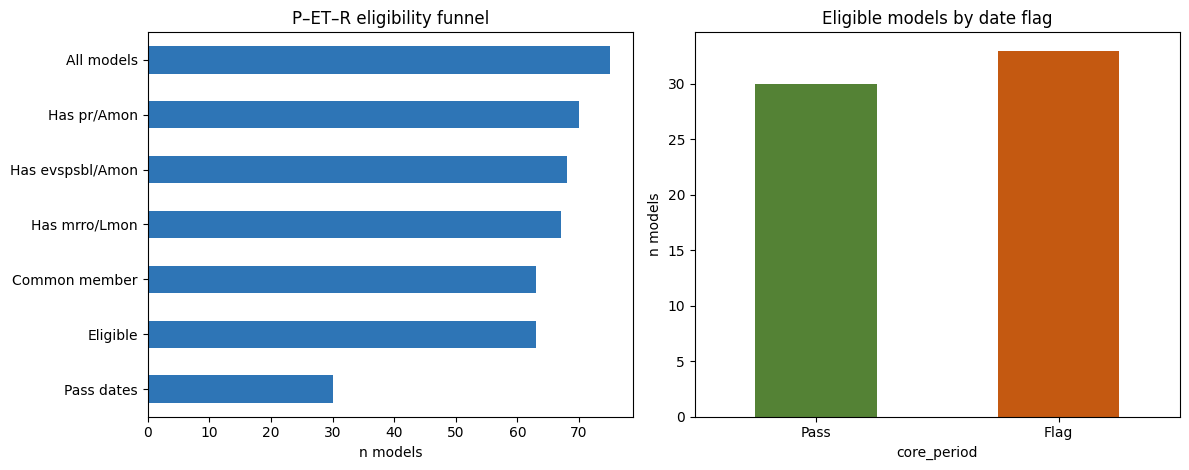

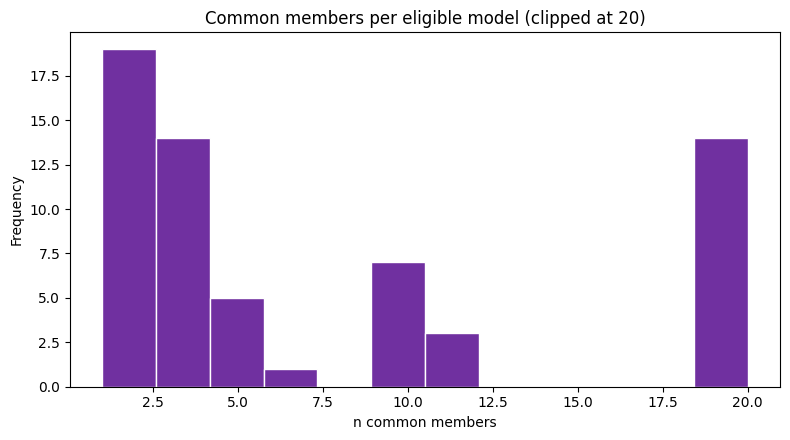

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

funnel = pd.Series(
    {
        "All models": len(result),
        "Has pr/Amon": int(result["pr_Amon"].sum()),
        "Has evspsbl/Amon": int(result["evspsbl_Amon"].sum()),
        "Has mrro/Lmon": int(result["mrro_Lmon"].sum()),
        "Common member": int((result["n_common_members"] > 0).sum()),
        "Eligible": len(eligible),
        "Pass dates": int((eligible["core_period"] == "Pass").sum()),
    }
)
funnel.plot.barh(ax=axes[0], color="#2E75B6")
axes[0].invert_yaxis()
axes[0].set_title("P–ET–R eligibility funnel")
axes[0].set_xlabel("n models")

period_counts = eligible["core_period"].value_counts().reindex(["Pass", "Flag"]).fillna(0)
period_counts.plot.bar(ax=axes[1], color=["#548235", "#C45911"], rot=0)
axes[1].set_title("Eligible models by date flag")
axes[1].set_ylabel("n models")
fig.tight_layout()
fig.savefig(OUT_DIR / "S0_eligibility_funnel.png", dpi=150)
plt.show()

fig, ax = plt.subplots(figsize=(8, 4.5))
eligible["n_common_members"].clip(upper=20).plot.hist(bins=12, ax=ax, color="#7030A0", edgecolor="white")
ax.set_title("Common members per eligible model (clipped at 20)")
ax.set_xlabel("n common members")
fig.tight_layout()
fig.savefig(OUT_DIR / "S0_common_members.png", dpi=150)
plt.show()

## 8. Save / 保存

Write the full model table, the eligible shortlist, and the one-per-family pick. These files are the input for later download / Case A expansion, not a replacement of the 1103-variable catalog.

**中文说明：** 写出全模型表、合格短名单、每家族一个。供后续下载和扩展 Case A，不替代 1103 变量目录。

In [8]:
full_path = OUT_DIR / "S0_historical_PETR_model_table.csv"
elig_path = OUT_DIR / "S0_historical_PETR_eligible.csv"
fam_path = OUT_DIR / "S0_historical_PETR_one_per_family.csv"
batch_path = OUT_DIR / "S0_historical_PETR_first_batch.csv"

result.to_csv(full_path, index=False)
eligible.to_csv(elig_path, index=False)
family_pick.to_csv(fam_path, index=False)
first_batch.to_csv(batch_path, index=False)

print("Wrote")
for path in (full_path, elig_path, fam_path, batch_path):
    print(" ", path)

mpi = result.loc[result["model"] == "MPI-ESM1-2-LR"].iloc[0]
print("\nMPI-ESM1-2-LR already used in Case A:")
print(
    f"  {mpi['decision']}; member={mpi['recommended_member']}; "
    f"period={mpi['core_period']}; grid={mpi['core_grids']}"
)


Wrote
  /Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/case/caseA/derived/catalog_s0/S0_historical_PETR_model_table.csv
  /Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/case/caseA/derived/catalog_s0/S0_historical_PETR_eligible.csv
  /Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/case/caseA/derived/catalog_s0/S0_historical_PETR_one_per_family.csv
  /Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/case/caseA/derived/catalog_s0/S0_historical_PETR_first_batch.csv

MPI-ESM1-2-LR already used in Case A:
  Eligible; member=r1i1p1f1; period=Flag; grid=gn
